#  Dataset Importing and Overview

In [1]:
#Importing necessary libraries for data cleaning and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [14]:
#Importing the data set and showing its number of rows and columns, respectively
df = pd.read_csv('https://raw.githubusercontent.com/Youssef-888/Procurement-Spend-Analysis/refs/heads/main/spend_analysis_dataset.csv')
df.shape

(500, 9)

In [15]:
#Showing first 5 rows of the data set
df.head()

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer
0,TXN001,Desk Chair,Furniture,10,113.15,1131.50,2024-04-19,TechMart Inc.,Kelly Joseph
1,TXN002,Stapler,Office Supplies,16,12.62,201.92,2024-07-06,CloudSoft Corp.,Kelly Joseph
2,TXN003,Annual Software License,Software,1,5649.34,5649.34,2024-09-10,TechMart Inc.,Kelly Joseph
3,TXN004,Notepad,Stationery,13,2.92,37.96,2024-01-21,FurniWorks Ltd.,Luis Holland
4,TXN005,Notepad,Stationery,19,1.39,26.41,2024-02-03,TechMart Inc.,Cynthia Jenkins


In [16]:
#Showing the last 5 rows of the data set
df.tail()

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer
495,TXN496,Whiteboard,Furniture,19,104.12,1978.28,2024-08-20,QuickDeliver Ltd.,Noah Long
496,TXN497,Laptop,Electronics,5,919.08,4595.40,2024-08-15,OfficeSupplies Co.,Walter Pena
497,TXN498,Notepad,Stationery,3,1.51,4.53,2024-05-12,QuickDeliver Ltd.,Jessica Hodges
498,TXN499,Whiteboard,Furniture,17,162.01,2754.17,2024-03-14,FurniWorks Ltd.,Rebecca Bell
499,TXN500,Stapler,Office Supplies,4,13.64,54.56,2024-03-02,TechMart Inc.,Noah Long


In [ ]:
#Displaying important measures for quantitative data set columns
df.describe()

,Quantity,UnitPrice,TotalCost
count,500.000000,500.000000,500.00000
mean,9.640000,854.245100,2481.16106
std,6.168834,2132.890832,3527.35316
min,1.000000,1.060000,1.56000
25%,4.000000,14.380000,145.92750
50%,10.000000,143.595000,918.56000
75%,15.000000,287.925000,3123.56750
max,20.000000,9909.240000,18494.60000


# Which Suppliers Account for the Highest Proportion of Total Spending?


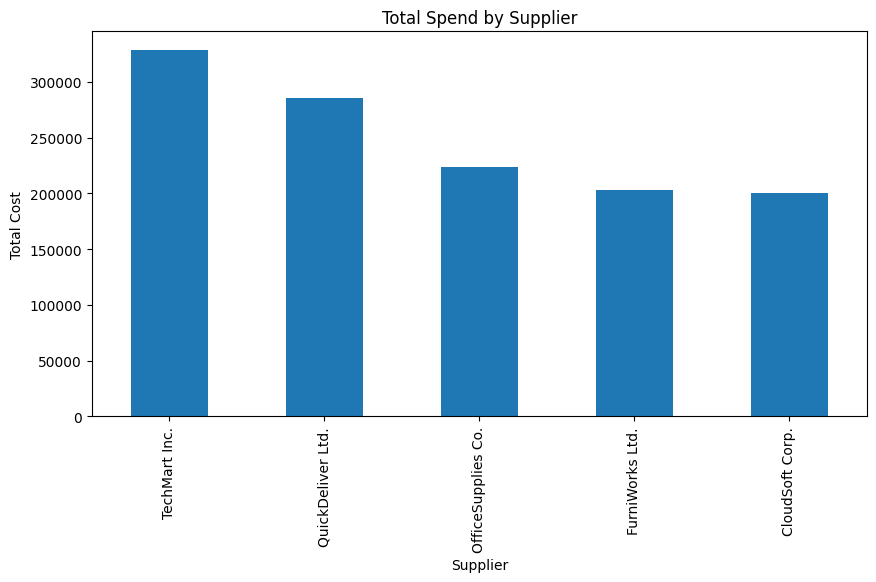

In [ ]:
# Group the DataFrame by 'Supplier' and sum the 'TotalCost' for each supplier
top_suppliers = df.groupby('Supplier')['TotalCost'].sum().sort_values(ascending=False)

# Create a bar plot to visualize the total cost per supplier, sorted in descending order
top_suppliers.plot(kind='bar', figsize=(10, 5), title='Total Spend by Supplier')

# Label the y-axis as 'Total Cost'
plt.ylabel('Total Cost')

# Display the plot
plt.show()


# Are There Seasonal Trends in Spending?

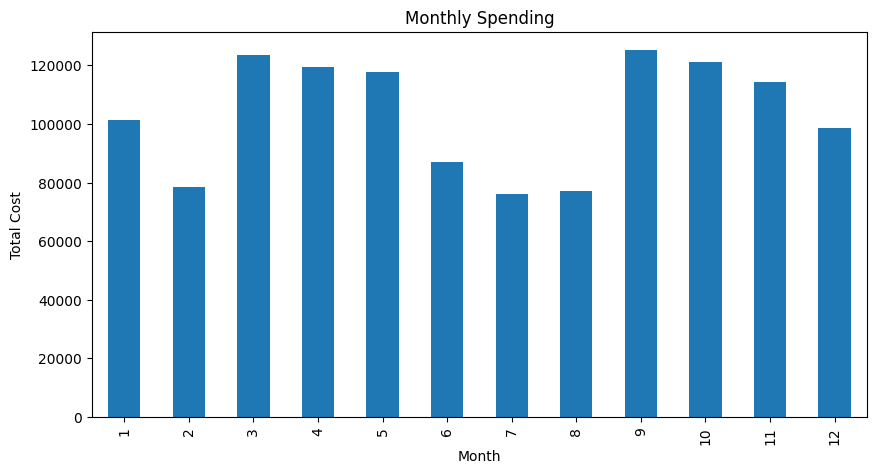

In [ ]:
# Convert the 'PurchaseDate' column to datetime format
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# Extract the month from 'PurchaseDate' and create a new 'Month' column
df['Month'] = df['PurchaseDate'].apply(lambda x: x.month)

# Group the data by 'Month' and sum the 'TotalCost' for each month
monthly_spending = df.groupby('Month')['TotalCost'].sum()

monthly_spending.plot(kind='bar', figsize=(10, 5), title='Monthly Spending')

plt.xlabel('Month')

plt.ylabel('Total Cost')

plt.show()


# Is Spending Higher in Q4 Than Q1?

Average Q1 Spending: $2283.52
Average Q4 Spending: $2982.34


<ipython-input-43-5148b8ac72cf>:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([q1, q4], labels=['Q1', 'Q4'])


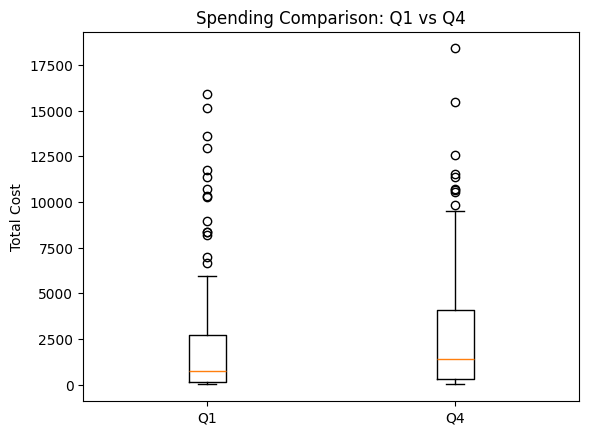

In [ ]:
# Define a function to assign a quarter based on the month
def get_quarter(month):
    if month in [1, 2, 3]:
        return 1  # Q1
    elif month in [4, 5, 6]:
        return 2  # Q2
    elif month in [7, 8, 9]:
        return 3  # Q3
    else:
        return 4  # Q4

# Apply the function to create a new 'Quarter' column in the DataFrame
df['Quarter'] = df['Month'].apply(get_quarter)

# Filter the 'TotalCost' values for Q1 and Q4
q1 = df[df['Quarter'] == 1]['TotalCost']
q4 = df[df['Quarter'] == 4]['TotalCost']

# Print the average spending for Q1 and Q4
print(f"Average Q1 Spending: ${q1.mean():.2f}")
print(f"Average Q4 Spending: ${q4.mean():.2f}")

# Create a boxplot to compare the distribution of spending between Q1 and Q4
plt.boxplot([q1, q4], labels=['Q1', 'Q4'])
plt.title('Spending Comparison: Q1 vs Q4')
plt.ylabel('Total Cost')
plt.show()


In [ ]:
# Import the t-test function from SciPy
from scipy.stats import ttest_ind

# Perform a two-sample t-test assuming unequal variances (Welch's t-test)
t_stat, p_val_two_tailed = ttest_ind(q4, q1, equal_var=False)

# Convert the two-tailed p-value to a one-tailed p-value
# Since we're testing if Q4 spending is greater than Q1
p_val_one_tailed = p_val_two_tailed / 2

# Print the t-statistic and one-tailed p-value
print(f"T-statistic: {t_stat:.2f}")
print(f"One-tailed P-value: {p_val_one_tailed:.4f}")

alpha = 0.05

# Interpret the result of the hypothesis test
if p_val_one_tailed < alpha and t_stat > 0:
    print("Conclusion: Since p < 0.05 and the t-statistic is positive, we reject the null hypothesis.")
    print("There is evidence that Q4 spending is significantly higher than Q1.")
else:
    print("Conclusion: We fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that Q4 spending is significantly higher than Q1.")

T-statistic: 1.51
One-tailed P-value: 0.0667
Conclusion: We fail to reject the null hypothesis.
There is not enough evidence to conclude that Q4 spending is significantly higher than Q1.


We tested to see if the total spending in Q4 (October–December) is significantly higher than in Q1 (January–March).

Null Hypothesis (H0): There is no difference in mean spending between Q4 and Q1  
Alternative Hypothesis (Ha): Spending is higher in Q4 than in Q1

- T-statistic: 1.51
- P-value: 0.0667

Conclusion: Since p > 0.05, we fail to reject the null hypothesis. There is not enough evidence that Q4 spending is significantly higher than Q1.

# Are Higher Quantities Associated With Lower Unit Prices?

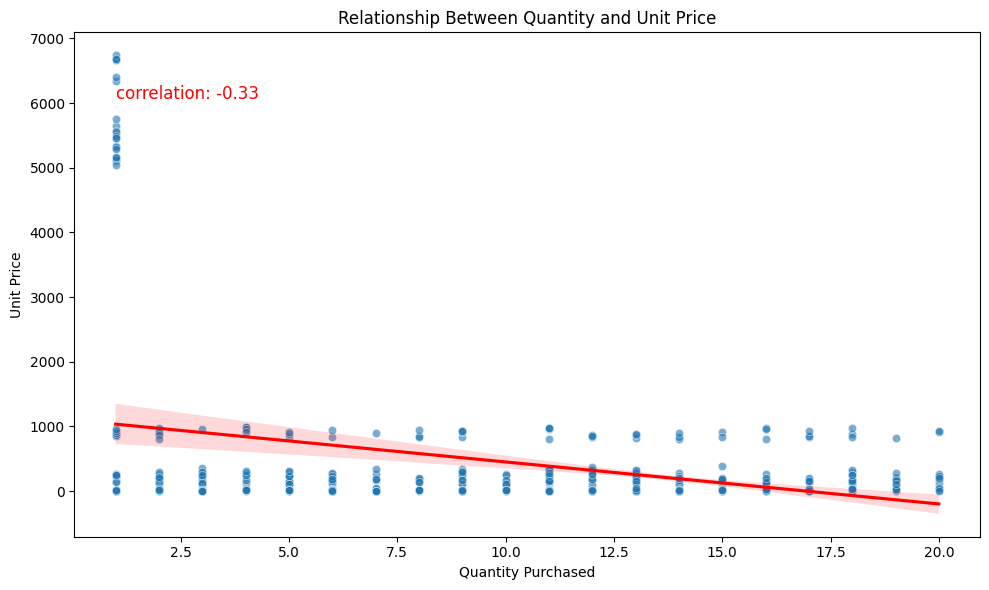

In [ ]:
# Filter out outliers by keeping only the data below the 95th percentile of 'UnitPrice'
filtered_df = df[df['UnitPrice'] < df['UnitPrice'].quantile(0.95)]

# Calculate the Pearson correlation coefficient between 'Quantity' and 'UnitPrice'
corr = filtered_df['Quantity'].corr(filtered_df['UnitPrice'])

plt.figure(figsize=(10, 6))

sns.scatterplot(data=filtered_df, x='Quantity', y='UnitPrice', alpha=0.6)

sns.regplot(data=filtered_df, x='Quantity', y='UnitPrice', scatter=False, color='red')

# Display the correlation value as text on the plot
plt.text(1, filtered_df['UnitPrice'].max()*0.9, f'correlation: {corr:.2f}', fontsize=12, color='red')

plt.title('Relationship Between Quantity and Unit Price')
plt.xlabel('Quantity Purchased')
plt.ylabel('Unit Price')

# Adjust layout to prevent overlapping elements
plt.tight_layout()

plt.show()


In [ ]:
filtered_df = df[df['UnitPrice'] < df['UnitPrice'].quantile(0.95)]
from scipy.stats import ttest_ind, pearsonr
# Run Pearson correlation test
r, p_value = pearsonr(filtered_df['Quantity'], filtered_df['UnitPrice'])

print(f"Correlation coefficient: {r:.2f}")
print(f"P-value: {p_value:.4f}")

Correlation coefficient: -0.33
P-value: 0.0000


#How does the distribution of unit prices vary across the top 4 most frequently purchased categories?



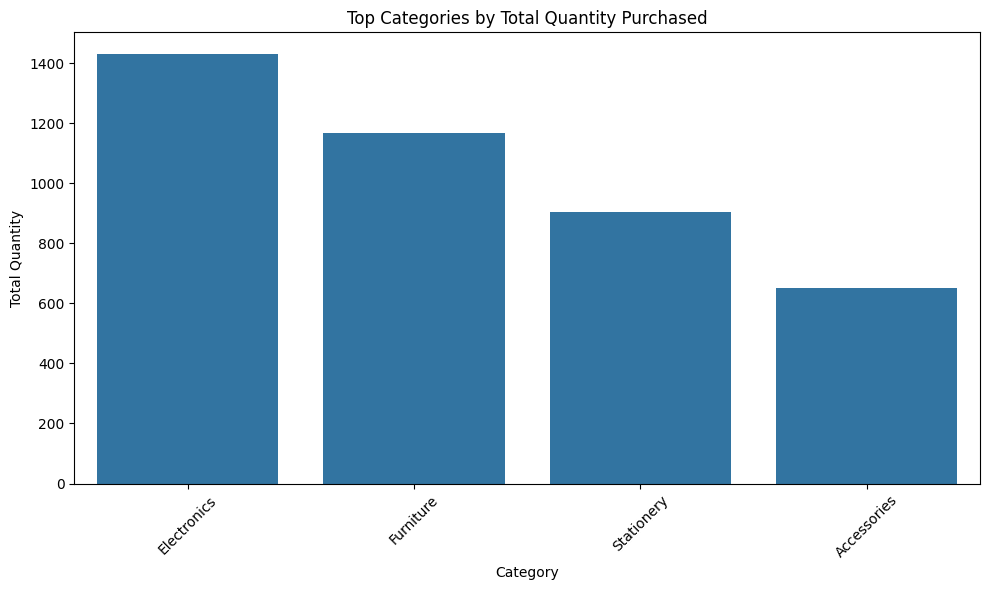

In [ ]:
# Group the DataFrame by 'Category' and sum the 'Quantity' for each category
# Then sort the categories in descending order of quantity and take the top 4
purshased_categories = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False).head(4)

# Create a figure with specified size for better readability
plt.figure(figsize=(10, 6))

sns.barplot(x=purshased_categories.index, y=purshased_categories.values)

plt.title("Top Categories by Total Quantity Purchased")
plt.xlabel("Category")
plt.ylabel("Total Quantity")

# Rotate x-axis labels for better visibility (in case of long category names)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


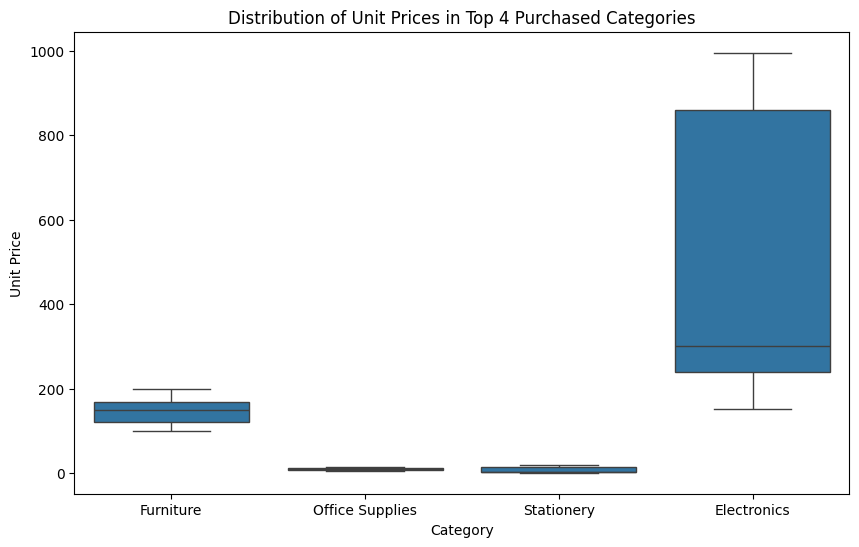

In [ ]:
# Get the top 4 most frequently occurring categories (based on count, not quantity)
top_categories = df['Category'].value_counts().head(4).index

# Filter the DataFrame to include only rows that belong to the top 4 categories
top_category_data = df[df['Category'].isin(top_categories)]

plt.figure(figsize=(10, 6))

sns.boxplot(data=top_category_data, x='Category', y='UnitPrice')

plt.title("Distribution of Unit Prices in Top 4 Purchased Categories")
plt.xlabel("Category")
plt.ylabel("Unit Price")

plt.show()


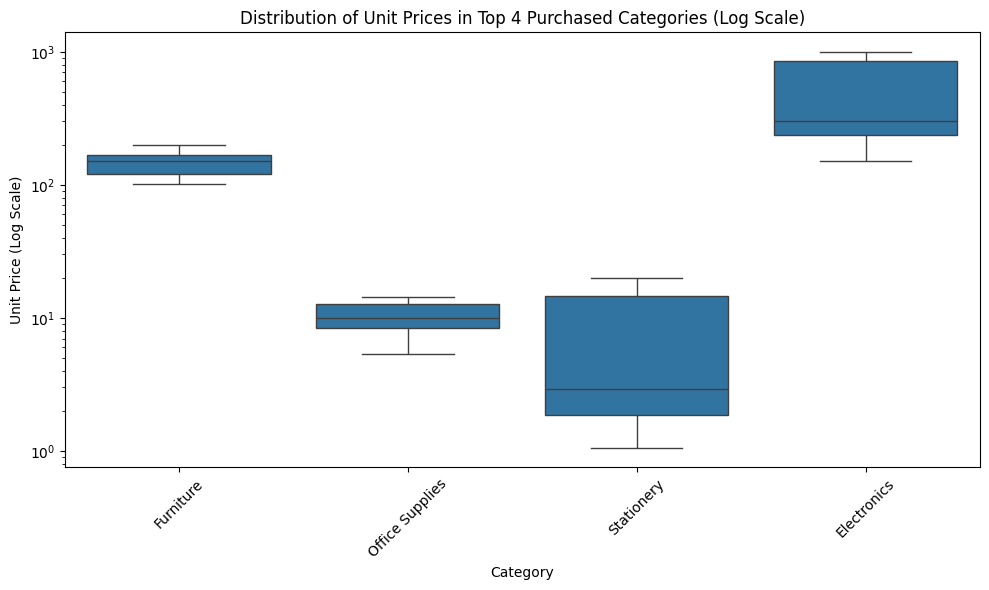

In [17]:
top_categories = df['Category'].value_counts().head(4).index

# Filter data for those categories
top_category_data = df[df['Category'].isin(top_categories)]

# Plot with log scale for better visibility
plt.figure(figsize=(10, 6))
sns.boxplot(data=top_category_data, x='Category', y='UnitPrice')
plt.yscale('log')
plt.title("Distribution of Unit Prices in Top 4 Purchased Categories (Log Scale)")
plt.xlabel("Category")
plt.ylabel("Unit Price (Log Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Which categories contribute the most to overall spending?


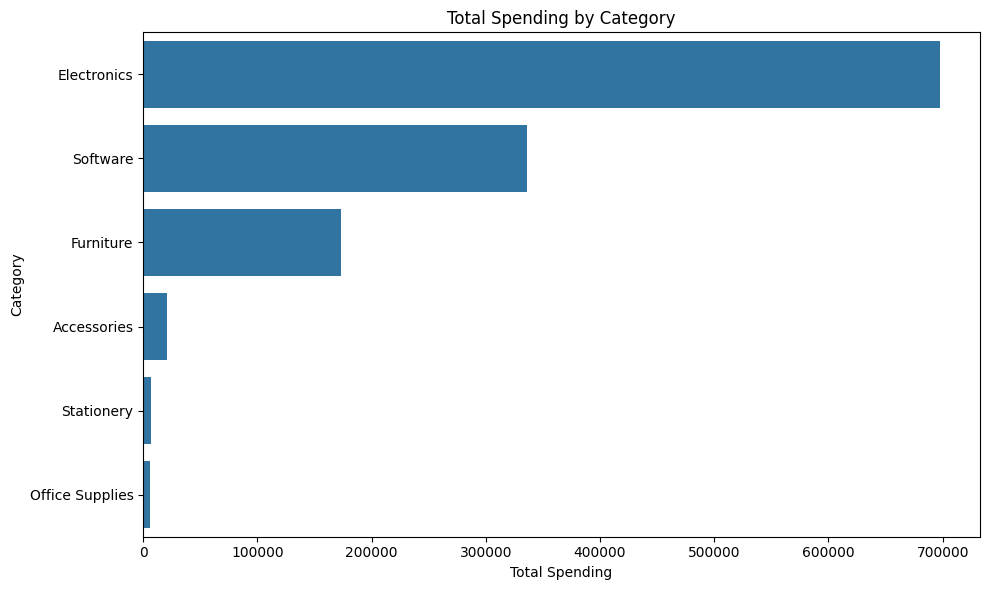

In [ ]:
# Group the data by 'Category' and sum the 'TotalCost' for each category
# Then sort the categories by total spending in descending order
category_spending = df.groupby('Category')['TotalCost'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x=category_spending.values, y=category_spending.index)

plt.title('Total Spending by Category')
plt.xlabel('Total Spending')
plt.ylabel('Category')

plt.tight_layout()

plt.show()


#Which buyers are responsible for the most spending, and what do they purchase the most?

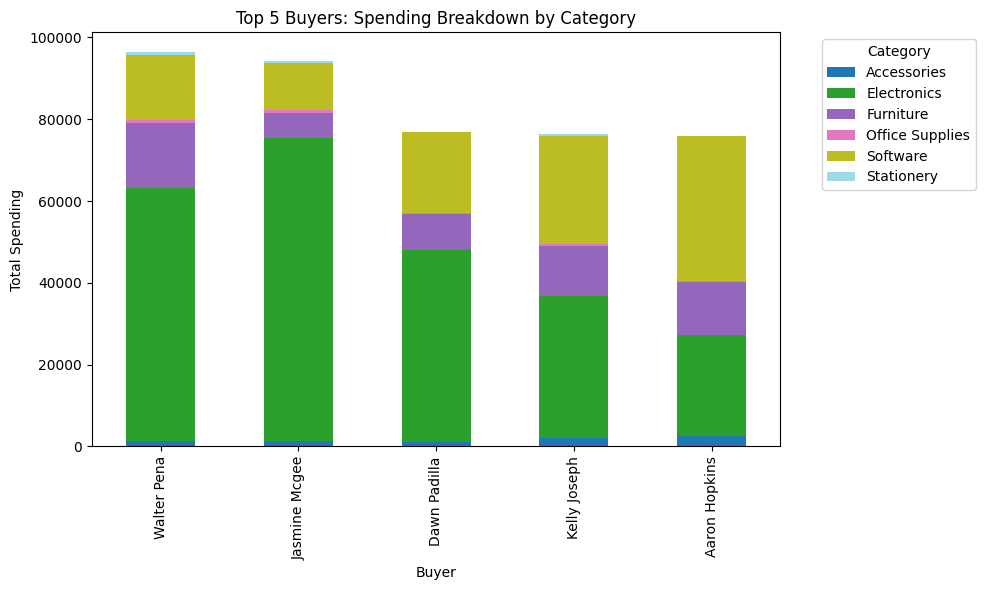

In [ ]:
# Group the data by both 'Buyer' and 'Category', summing the 'TotalCost'
# Then reshape the result to have categories as columns (wide format)
buyer_category_spend = df.groupby(['Buyer', 'Category'])['TotalCost'].sum().unstack().fillna(0)

# Identify the top 5 buyers based on total spending across all categories
topfive_buyers = buyer_category_spend.sum(axis=1).sort_values(ascending=False).head(5).index

# Filter the data to include only the top 5 buyers
topfive_data = buyer_category_spend.loc[topfive_buyers]

topfive_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')

plt.title('Top 5 Buyers: Spending Breakdown by Category')
plt.xlabel('Buyer')
plt.ylabel('Total Spending')

plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()


# Is there a correlation between unit price and total cost across categories?

In [ ]:
# Calculate the average unit price for each category
avg_unit_price = df.groupby('Category')['UnitPrice'].mean().reset_index()

# Calculate the total cost for each category
total_cost = df.groupby('Category')['TotalCost'].sum().reset_index()

# Merge the two DataFrames on the 'Category' column to combine average price and total cost
category_stats = pd.merge(avg_unit_price, total_cost, on='Category')


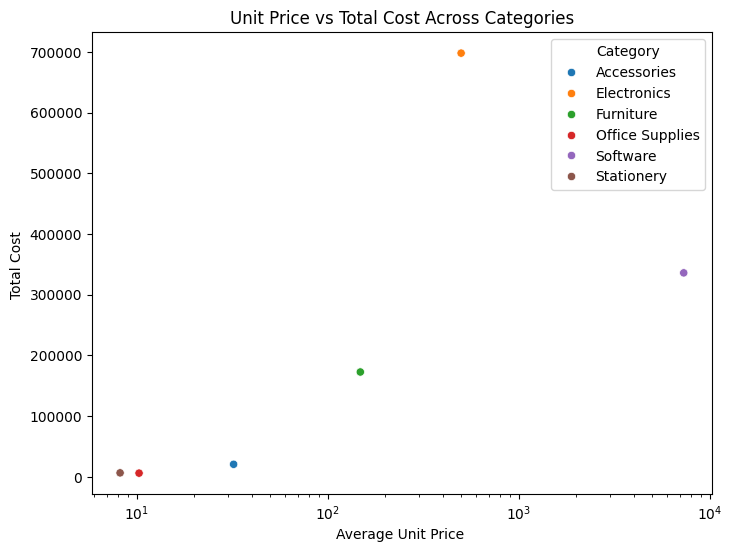

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=category_stats, x='UnitPrice', y='TotalCost', hue='Category')
plt.title('Unit Price vs Total Cost Across Categories')
plt.xscale('log')
plt.xlabel('Average Unit Price ')
plt.ylabel('Total Cost ')
plt.show()

# Extra Mile

**Time Series Breakdown**

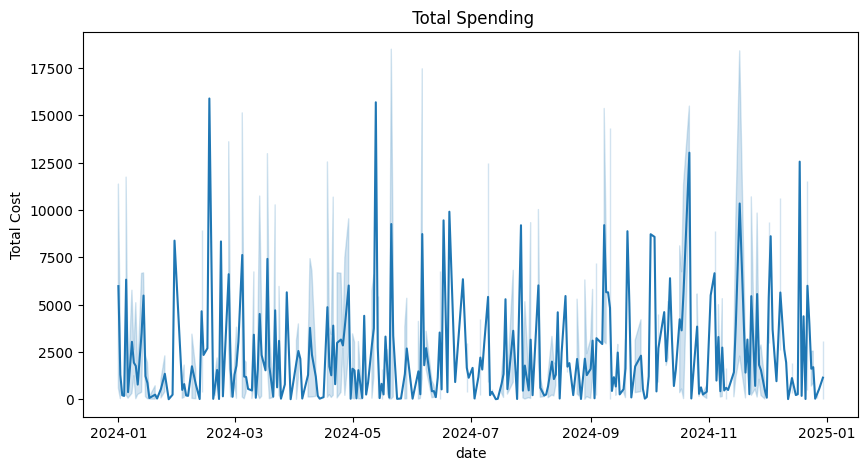

In [ ]:
# Create a figure with specified size for better visibility
plt.figure(figsize=(10, 5))

sns.lineplot(data=df, x='PurchaseDate', y='TotalCost')

plt.title('Total Spending')
plt.xlabel('Date')
plt.ylabel('Total Cost')

plt.show()


#Total outliers spending


In [19]:
# Calculate the 25th percentile (Q1) of 'UnitPrice'
Q1 = df['UnitPrice'].quantile(0.25)

# Calculate the 75th percentile (Q3) of 'UnitPrice'
Q3 = df['UnitPrice'].quantile(0.75)

# Compute the interquartile range (IQR)
IQR = Q3 - Q1

# Calculate the lower bound for outliers
lower_bound = Q1 - 1.5 * IQR

# Calculate the upper bound for outliers
upper_bound = Q3 + 1.5 * IQR

# Identify rows where 'UnitPrice' is outside the IQR bounds (outliers)
iqr_outliers = df[(df['UnitPrice'] < lower_bound) | (df['UnitPrice'] > upper_bound)]

# Sum the 'TotalCost' of these outlier transactions to see their overall spending impact
total_iqr_outlier_spending = iqr_outliers['TotalCost'].sum()

print("Outlier Transactions (IQR method):")
print(iqr_outliers[['TransactionID', 'Category', 'UnitPrice', 'TotalCost']].head())

print(total_iqr_outlier_spending)


Outlier Transactions (IQR method):
   TransactionID     Category  UnitPrice  TotalCost
2         TXN003     Software    5649.34    5649.34
10        TXN011     Software    8183.91    8183.91
18        TXN019  Electronics     815.19   15488.61
26        TXN027     Software    5099.86    5099.86
30        TXN031  Electronics     980.67   15690.72
808302.81


# Timeline after deleting the outliers

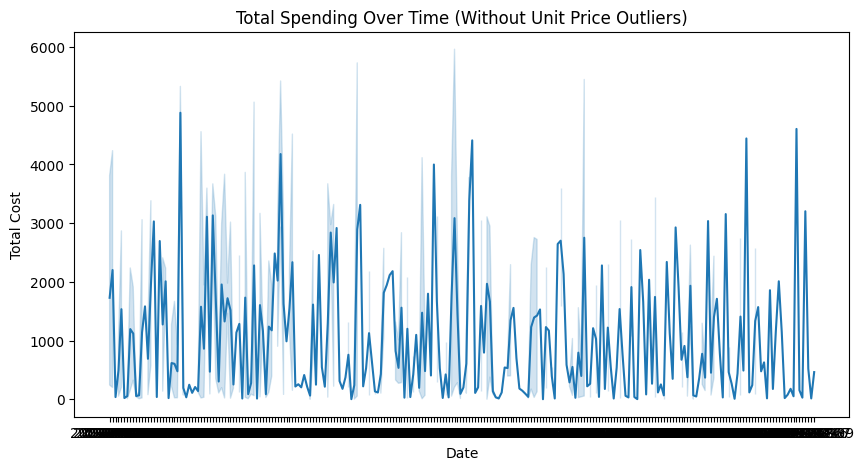

In [18]:
# Filter the DataFrame to exclude outliers based on UnitPrice using the previously calculated bounds
df_no_outliers = df[(df['UnitPrice'] >= lower_bound) & (df['UnitPrice'] <= upper_bound)]

plt.figure(figsize=(10, 5))

sns.lineplot(data=df_no_outliers, x='PurchaseDate', y='TotalCost')

plt.title('Total Spending Over Time (Without Unit Price Outliers)')
plt.xlabel('Date')
plt.ylabel('Total Cost')

plt.show()


#Buyer Spending Profiles

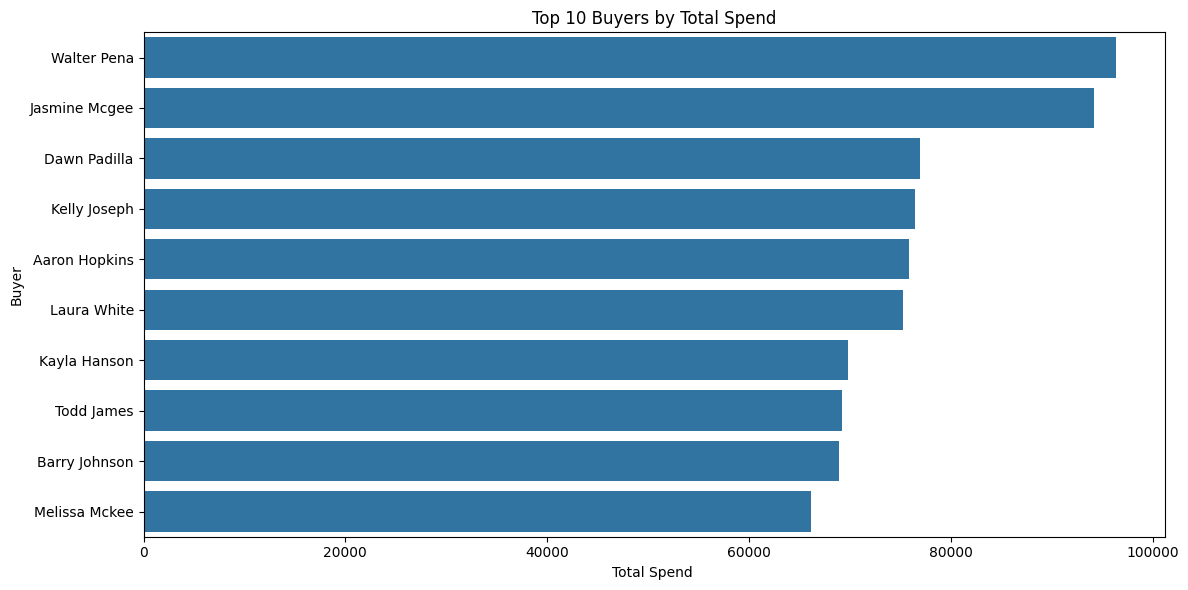

,Buyer,TotalSpend,NumPurchases,AvgQuantity
19,Walter Pena,96418.18,36,11.777778
5,Jasmine Mcgee,94185.73,33,9.424242
4,Dawn Padilla,76908.12,31,7.935484
8,Kelly Joseph,76434.12,33,9.212121
0,Aaron Hopkins,75865.04,27,9.888889
10,Laura White,75235.84,33,10.909091
7,Kayla Hanson,69848.40,24,9.000000
18,Todd James,69219.24,29,10.068966
2,Barry Johnson,68937.27,20,6.450000
13,Melissa Mckee,66169.71,20,8.450000


In [ ]:
buyer_profiles = df.groupby('Buyer').agg(
    TotalSpend=('TotalCost', 'sum'),
    NumPurchases=('TransactionID', 'count'),
    AvgQuantity=('Quantity', 'mean')
).reset_index()

top_buyers = buyer_profiles.sort_values(by='TotalSpend', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_buyers.head(10), x='TotalSpend', y='Buyer')
plt.title('Top 10 Buyers by Total Spend')
plt.xlabel('Total Spend ')
plt.ylabel('Buyer')
plt.tight_layout()
plt.show()

# Display the top 10 buyers' statistics
top_buyers.head(10)

# Do Top Buyers Spend More Per Purchase?

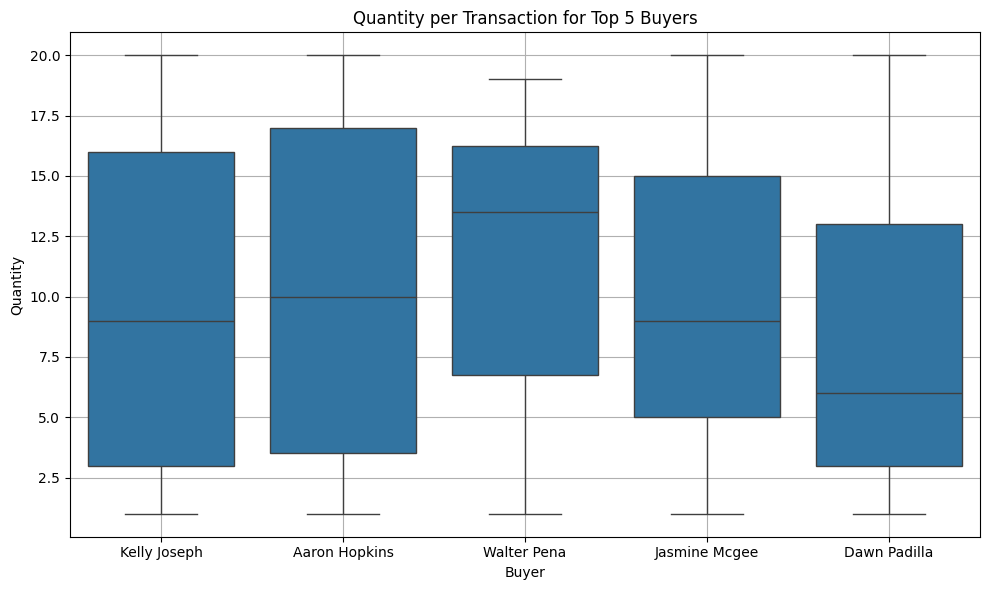

In [ ]:
top_buyer_names = top_buyers.head(10)['Buyer']
top5_buyers = top_buyer_names.head(5)
df_top5 = df[df['Buyer'].isin(top5_buyers)]
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top5, x='Buyer', y='Quantity')
plt.title('Quantity per Transaction for Top 5 Buyers')
plt.xlabel('Buyer')
plt.ylabel('Quantity')
plt.grid(True)
plt.tight_layout()
plt.show()

Null Hypothesis (H₀): All top 5 buyers have the same average quantity per transaction.

Alternative Hypothesis (H₁): At least one buyer has a significantly different average quantity.

In [ ]:
from scipy.stats import f_oneway
groups = [df[df['Buyer'] == buyer]['Quantity'] for buyer in top5_buyers]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Significant difference in quantity between at least two buyers.")
else:
    print("Result: No significant difference in quantity between buyers.")


ANOVA F-statistic: 1.6867
P-value: 0.1558
Result: No significant difference in quantity between buyers.


#Does Category, Month, or their interaction significantly affect TotalCost?

<ipython-input-25-926fb52201a8>:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(index='Category', columns='Month', values='TotalCost', aggfunc='sum', fill_value=0)


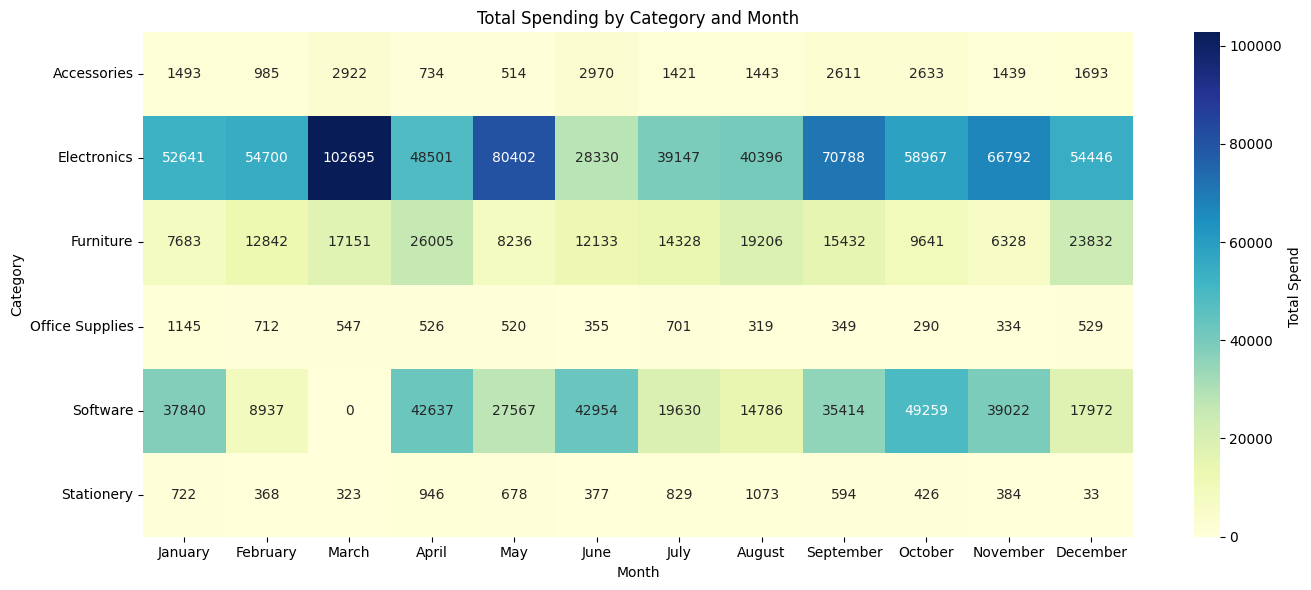

In [ ]:
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# Extract month name
df['Month'] = df['PurchaseDate'].dt.strftime('%B')  # e.g., January, February

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
             'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

pivot_table = df.pivot_table(index='Category', columns='Month', values='TotalCost', aggfunc='sum', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Total Spend '})
plt.title('Total Spending by Category and Month')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import f_oneway

# Group total cost by month
month_groups = [group['TotalCost'] for name, group in df.groupby('Month')]
f_stat, p_val = f_oneway(*month_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print(" Significant difference in spending across months.")
else:
    print(" No significant difference in spending across months.")


F-statistic: 0.6300
P-value: 0.8036
 No significant difference in spending across months.


<ipython-input-26-0d6aafd3f85a>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_groups = [group['TotalCost'] for name, group in df.groupby('Month')]


In [ ]:
# Group total cost by category
category_groups = [group['TotalCost'] for name, group in df.groupby('Category')]
f_stat, p_val = f_oneway(*category_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print(" Significant difference in spending across category.")
else:
    print(" No significant difference in spending across category.")

F-statistic: 93.1732
P-value: 0.0000
 Significant difference in spending across category.


#Is there any correlation between categories and spending?


<ipython-input-28-58a17641ba6f>:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(index='Category', columns='Month', values='TotalCost', aggfunc='sum', fill_value=0)


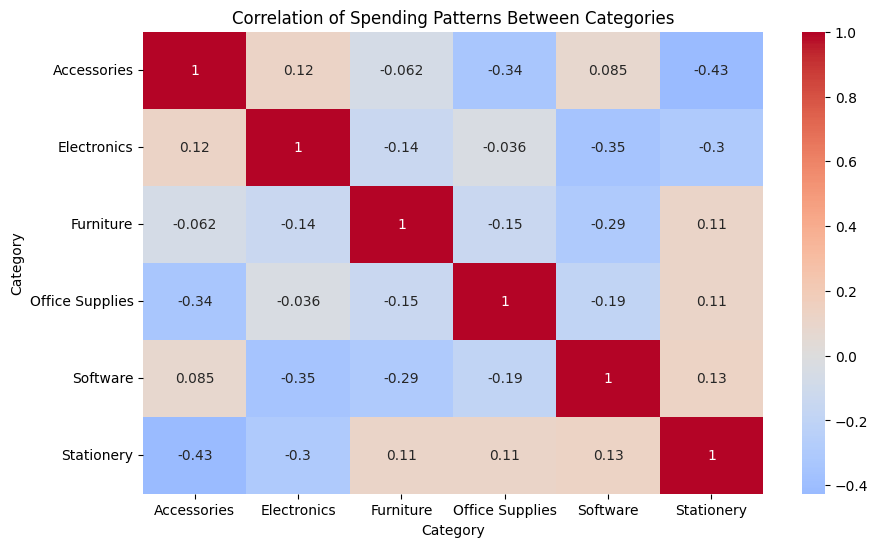

In [ ]:
pivot_table = df.pivot_table(index='Category', columns='Month', values='TotalCost', aggfunc='sum', fill_value=0)

category_corr = pivot_table.T.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(category_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation of Spending Patterns Between Categories')
plt.show()